C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\679180546.py:14: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\679180546.py:14: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\679180546.py:14: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)


=== Channel List ===
['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']

Sampling Frequency: 100.0 Hz
Total Duration: 22.08 hours
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

=== Selected Channels ===
['EEG Fpz-Cz', 'EOG horizontal', 'EMG submental', 'Resp oro-nasal']

=== Annotation Load Results ===
Total Epochs: 153
  W: 12
  N1: 24
  N2: 40
  N3: 71
  REM: 6

=== Epochs Creation Results ===
Epochs shape: (153, 4, 3001)


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\679180546.py:32: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_selected.set_annotations(annotations)


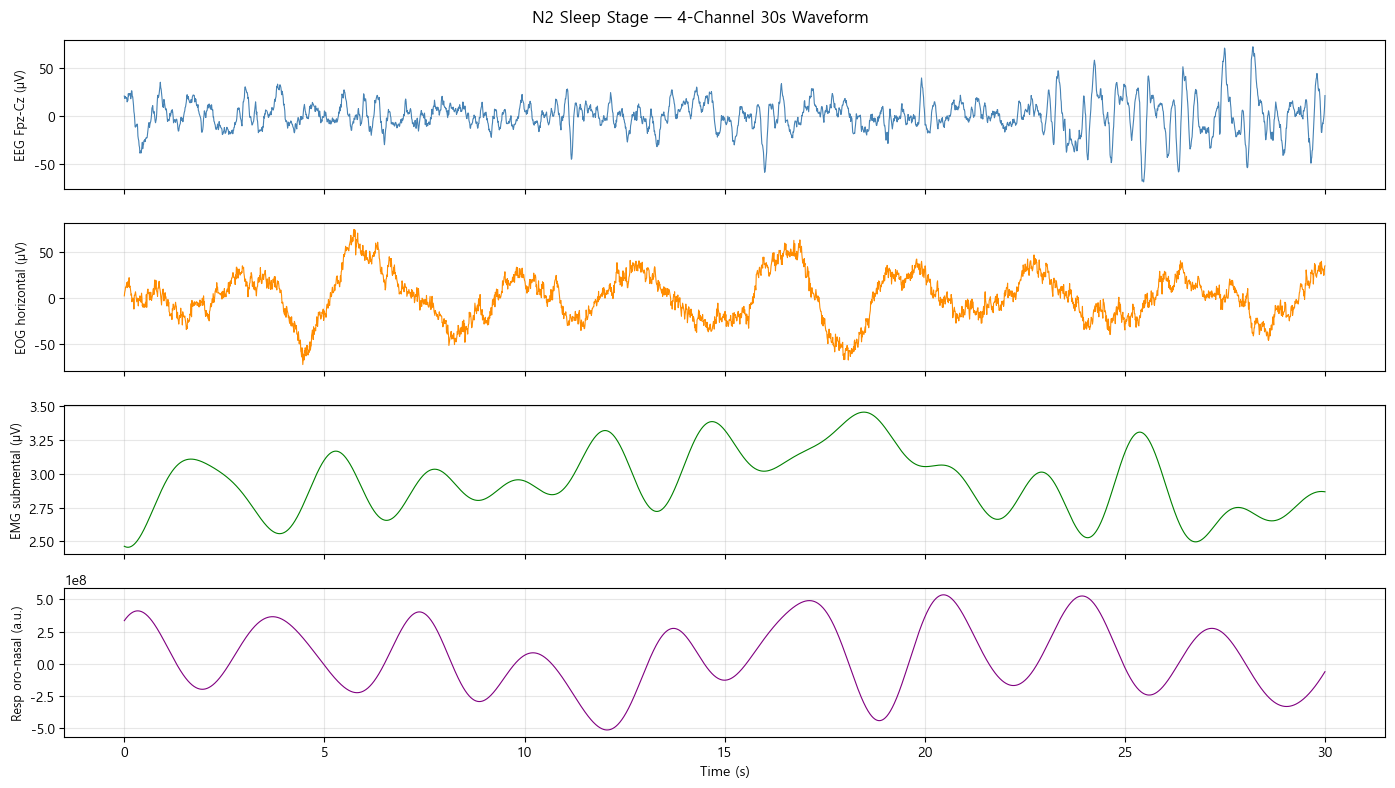


Image saved: step2_4channel_waveform.png


In [1]:
# STEP 1 — Data Loading & Signal Verification (Single Subject)
import matplotlib.pyplot as plt
import mne
import numpy as np

# Set plotting parameters for visualization
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

PSG_PATH = r"SC4001E0-PSG.edf"
HYPO_PATH = r"SC4001EC-Hypnogram.edf"

# ── 1. Load Raw PSG Data ──────────────────────────────────────
raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)

print("=== Channel List ===")
print(raw.ch_names)

print(f"\nSampling Frequency: {raw.info['sfreq']} Hz")
print(f"Total Duration: {raw.times[-1] / 3600:.2f} hours")

# ── 2. Channel Selection ──────────────────────────────────────
# Selecting standard channels based on Sleep-EDF Cassette dataset
CHANNELS = ['EEG Fpz-Cz', 'EOG horizontal', 'EMG submental', 'Resp oro-nasal']
raw_selected = raw.pick_channels(CHANNELS)

print("\n=== Selected Channels ===")
print(raw_selected.ch_names)

# ── 3. Load & Map Sleep Stage Annotations ───────────────────
annotations = mne.read_annotations(HYPO_PATH)
raw_selected.set_annotations(annotations)

# Mapping annotations to numerical events (AASM Standard)
event_id = {
    'Sleep stage W':   0,
    'Sleep stage 1':   1,
    'Sleep stage 2':   2,
    'Sleep stage 3':   3,
    'Sleep stage 4':   3,  # Integrated into N3
    'Sleep stage R':   4,
}

events, _ = mne.events_from_annotations(
    raw_selected,
    event_id=event_id,
    verbose=False
)

print(f"\n=== Annotation Load Results ===")
print(f"Total Epochs: {len(events)}")

# Check epoch counts per sleep stage
stage_names = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
for stage_id, stage_name in stage_names.items():
    count = np.sum(events[:, 2] == stage_id)
    print(f"  {stage_name}: {count}")

# ── 4. Epoching (30s Window Segmentation) ───────────────────
# Segmenting data into 30-second windows based on event onset
epochs = mne.Epochs(
    raw_selected,
    events,
    event_id=list(event_id.values()),
    tmin=0,
    tmax=30,
    baseline=None,   # Baseline correction skipped for sleep data
    preload=True,
    verbose=False
)

print(f"\n=== Epochs Creation Results ===")
print(f"Epochs shape: {epochs.get_data().shape}")
# Shape: (n_epochs, n_channels, n_times)

# ── 5. Signal Visualization (4-Channel Parallel Plot) ───────
# Visualizing a single N2 stage epoch as an example
n2_indices = np.where(events[:, 2] == 2)[0]
sample_epoch = epochs[n2_indices[0]].get_data()[0] 

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
channel_labels = ['EEG Fpz-Cz (μV)', 'EOG horizontal (μV)',
                  'EMG submental (μV)', 'Resp oro-nasal (a.u.)']
colors = ['steelblue', 'darkorange', 'green', 'purple']

time_axis = np.linspace(0, 30, sample_epoch.shape[1])

for i, (ax, label, color) in enumerate(zip(axes, channel_labels, colors)):
    # Convert Volts(V) to Microvolts(μV) for EEG/EOG/EMG
    ax.plot(time_axis, sample_epoch[i] * 1e6, color=color, linewidth=0.8)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("N2 Sleep Stage — 4-Channel 30s Waveform", fontsize=12)
plt.tight_layout()
plt.savefig("step2_4channel_waveform.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved: step2_4channel_waveform.png")

In [2]:
# STEP 2 — Feature Extraction (2 subjects, exploratory)
import mne
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, welch

# ── 0. Configuration ──────────────────────────────────────────
PSG_PATHS = [
    r"SC4001E0-PSG.edf",
    r"SC4002E0-PSG.edf",
]
HYPO_PATHS = [
    r"SC4001EC-Hypnogram.edf",
    r"SC4002EC-Hypnogram.edf",
]

CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal']
SFREQ    = 100.0

event_id = {
    'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
    'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4,
}

# ── 1. Data Loading & Concatenation ───────────────────────────
all_epochs = []
for psg_path, hypo_path in zip(PSG_PATHS, HYPO_PATHS):
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    raw.pick_channels(CHANNELS)
    raw.set_annotations(mne.read_annotations(hypo_path))
    
    events, _ = mne.events_from_annotations(raw, event_id=event_id, verbose=False)
    # Segmenting into 30s epochs
    epochs = mne.Epochs(raw, events, event_id=list(set(event_id.values())),
                        tmin=0, tmax=30, baseline=None, preload=True, verbose=False)
    all_epochs.append(epochs)

# Combine datasets from multiple subjects
epochs_combined = mne.concatenate_epochs(all_epochs)
data   = epochs_combined.get_data().copy()  # Shape: (n_epochs, n_channels, n_times)
labels = epochs_combined.events[:, 2]

# ── 2. Respiration Preprocessing: Global Z-score Normalization ──
# Apply global normalization to preserve relative amplitude differences between epochs.
# This ensures that 'resp_std' remains a meaningful feature for identifying sleep stages.
resp_all    = data[:, 3, :]                 
global_mean = np.mean(resp_all)             
global_std  = np.std(resp_all)              
data[:, 3, :] = (resp_all - global_mean) / global_std  

print("=== Respiration Preprocessing Check ===")
print(f"Global Range: {data[:, 3, :].min():.4f} ~ {data[:, 3, :].max():.4f}")
print(f"Sample Epoch STDs: {[round(np.std(data[i, 3, :]), 4) for i in range(5)]}")

# ── 3. Feature Extraction Functions ───────────────────────────

def eeg_band_powers(signal, sfreq):
    """
    Calculate Power Spectral Density (PSD) using Welch's method.
    nperseg=256 (~2.56s) provides a stable estimation for sleep bands.
    """
    freqs, psd = welch(signal, fs=sfreq, nperseg=256)
    bands = {'delta': (0.5, 4), 'theta': (4, 8),
             'alpha': (8, 13), 'beta': (13, 30)}
    return {name: np.mean(psd[(freqs >= lo) & (freqs < hi)])
            for name, (lo, hi) in bands.items()}

def eog_features(signal):
    """
    Extract Eye Movement features:
    - RMS: Signal intensity (Arousal/Deep sleep detection)
    - ZCR: Crossing rate (Effective for detecting REM sleep)
    """
    rms = np.sqrt(np.mean(signal ** 2))
    zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
    return {'rms': rms, 'zcr': zcr}

def resp_features(signal, sfreq):
    """
    Extract Respiratory features:
    - Breath Rate: Frequency of breathing (BPM)
    - Resp STD: Relative amplitude variation preserved by global scaling
    """
    # Detect peaks with a minimum 2s distance (max 30 bpm)
    peaks, _ = find_peaks(signal,
                          distance=int(sfreq * 2),
                          prominence=np.std(signal) * 0.3)
    
    breath_rate = (len(peaks) / 30.0) * 60.0 if len(peaks) > 0 else 0.0
    resp_std    = np.std(signal)
    return {'rate': breath_rate, 'std': resp_std}

# ── 4. Main Feature Extraction Loop ───────────────────────────
# Channel Map: 0:EEG Fpz, 1:EEG Pz, 2:EOG, 3:Respiration
feature_rows = []
for i in range(len(data)):
    row = {}
    # EEG Frequency Features
    for name, val in eeg_band_powers(data[i, 0, :], SFREQ).items():
        row[f'fpz_{name}'] = val  
    for name, val in eeg_band_powers(data[i, 1, :], SFREQ).items():
        row[f'poz_{name}'] = val  
    # EOG Time-domain Features
    for name, val in eog_features(data[i, 2, :]).items():
        row[f'eog_{name}'] = val  
    # Respiration Features
    for name, val in resp_features(data[i, 3, :], SFREQ).items():
        row[f'resp_{name}'] = val 
    feature_rows.append(row)

df = pd.DataFrame(feature_rows)
df['label'] = labels

# ── 5. Data Validation ────────────────────────────────────────
print("\n=== Feature DataFrame Summary ===")
print(f"Final Shape: {df.shape}")
print(f"Respiration STD Sample (First 10):")
print(df['resp_std'].head(10).values)

print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Infinite Values: {np.isinf(df.drop('label', axis=1)).sum().sum()}")

C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
303 matching events found
No baseline correction applied


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\2566305822.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_combined = mne.concatenate_epochs(all_epochs)


=== Respiration Preprocessing Check ===
Global Range: -4.8356 ~ 4.0552
Sample Epoch STDs: [np.float64(0.8207), np.float64(0.5096), np.float64(0.4413), np.float64(0.656), np.float64(0.6701)]

=== Feature DataFrame Summary ===
Final Shape: (303, 13)
Respiration STD Sample (First 10):
[0.82070512 0.50964264 0.44133755 0.65596585 0.67005433 0.63278061
 0.64474314 0.62833501 0.6963335  0.64943481]

Missing Values: 0
Infinite Values: 0


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp

...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:45: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(mne.read_annotations(hypo_path))
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:120: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feat_prev = feat_df.shift(1).fillna(method='bfill')
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:121: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feat_next = feat_df.shift(-1).fillna(method='ffill')
C:\Users\aaww8\AppData\Local\Temp\ipykernel_2856\506679909.py:120: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feat_prev = feat_df.shift(1).fillna(method='bfill')
C:\Users\aaww8\AppData\

=== Feature Engineering Summary ===
Dataset Shape: (943, 46)
Missing Values: 0
Inf Values: 0

Training Samples: 754 / Test Samples: 189

=== Classification Performance Report ===
              precision    recall  f1-score   support

           W       1.00      0.80      0.89        20
          N1       0.83      0.89      0.86        38
          N2       0.83      0.83      0.83        59
          N3       0.88      0.91      0.90        58
         REM       0.85      0.79      0.81        14

    accuracy                           0.86       189
   macro avg       0.88      0.84      0.86       189
weighted avg       0.87      0.86      0.86       189



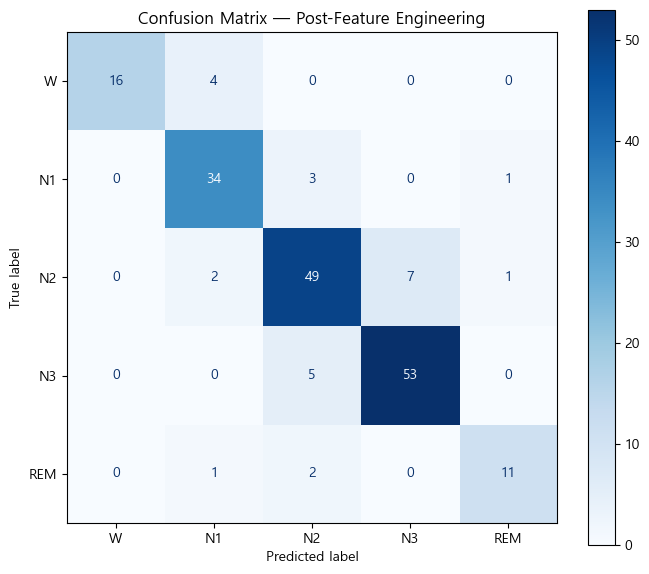


Total Features utilized: 45
Model check complete.


In [3]:
# STEP 3 — Feature Engineering & RF Classifier (7 subjects, final)
import mne
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import os  # Added for path management
from scipy.signal import find_peaks, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ── 0. Configuration (Relative Path for Portfolios) ───────────
# Set save_dir to "." to refer to the current script directory.
# This ensures the code is portable across different environments.
save_dir = "." 

PSG_PATHS = [f"{save_dir}/SC4001E0-PSG.edf", f"{save_dir}/SC4002E0-PSG.edf",
             f"{save_dir}/SC4011E0-PSG.edf", f"{save_dir}/SC4021E0-PSG.edf",
             f"{save_dir}/SC4031E0-PSG.edf", f"{save_dir}/SC4041E0-PSG.edf",
             f"{save_dir}/SC4051E0-PSG.edf"]

HYPO_PATHS = [f"{save_dir}/SC4001EC-Hypnogram.edf", f"{save_dir}/SC4002EC-Hypnogram.edf",
              f"{save_dir}/SC4011EH-Hypnogram.edf", f"{save_dir}/SC4021EH-Hypnogram.edf",
              f"{save_dir}/SC4031EC-Hypnogram.edf", f"{save_dir}/SC4041EC-Hypnogram.edf",
              f"{save_dir}/SC4051EC-Hypnogram.edf"]

CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal']
SFREQ    = 100.0

event_id = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
            'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}

# ── 1. Data Loading & Respiration Preprocessing ───────────────
all_data   = []   # Raw data per subject for lagged feature boundary handling
all_labels = []   # Labels per subject

for psg_path, hypo_path in zip(PSG_PATHS, HYPO_PATHS):
    # Check if files exist before loading (Recommended for portability)
    if not os.path.exists(psg_path):
        print(f"Warning: File not found - {psg_path}")
        continue
        
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    raw.pick_channels(CHANNELS)
    raw.set_annotations(mne.read_annotations(hypo_path))
    events, _ = mne.events_from_annotations(raw, event_id=event_id, verbose=False)
    epochs = mne.Epochs(raw, events, event_id=list(set(event_id.values())),
                        tmin=0, tmax=30, baseline=None, preload=True, verbose=False)
    all_data.append(epochs.get_data().copy()) 
    all_labels.append(epochs.events[:, 2])

# Global Z-score for Respiration to preserve inter-epoch amplitude variance
data_all   = np.concatenate(all_data, axis=0) 
labels_all = np.concatenate(all_labels, axis=0)

resp_all          = data_all[:, 3, :]
data_all[:, 3, :] = (resp_all - np.mean(resp_all)) / np.std(resp_all)

# Re-split by subject to handle temporal context (Lagged Features) correctly
subject_sizes = [d.shape[0] for d in all_data]
split_indices = np.cumsum(subject_sizes)[:-1]
data_per_subj  = np.split(data_all,   split_indices, axis=0)
label_per_subj = np.split(labels_all, split_indices, axis=0)

# ── 2. Feature Definition Functions ───────────────────────────

def eeg_band_powers(signal, sfreq):
    """Calculate PSD for standard sleep bands + Sigma (Spindles)"""
    freqs, psd = welch(signal, fs=sfreq, nperseg=256)
    bands = {
        'delta': (0.5, 4),  # Indicator for N3
        'theta': (4, 8),    # Indicator for N1/REM
        'alpha': (8, 12),   # Indicator for Wakefulness
        'sigma': (12, 15),  # Key feature for N2 (Sleep Spindles)
        'beta':  (15, 30),  # High-frequency activity
    }
    return {name: np.mean(psd[(freqs >= lo) & (freqs < hi)])
            for name, (lo, hi) in bands.items()}

def eog_features(signal):
    """Extract Eye Movement intensity and variance"""
    rms = np.sqrt(np.mean(signal ** 2))
    zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
    # Variance of first derivative to capture rapid eye movements in REM
    diff_var = np.var(np.diff(signal))
    return {'rms': rms, 'zcr': zcr, 'diff_var': diff_var}

def resp_features(signal, sfreq):
    """Extract Respiratory Rate and Amplitude Variation"""
    peaks, _ = find_peaks(signal, distance=int(sfreq * 2),
                          prominence=np.std(signal) * 0.3)
    breath_rate = (len(peaks) / 30.0) * 60.0 if len(peaks) > 0 else 0.0
    return {'rate': breath_rate, 'std': np.std(signal)}

def extract_features(epoch):
    """Combine all channel features (15 core features)"""
    row = {}
    for name, val in eeg_band_powers(epoch[0, :], SFREQ).items():
        row[f'fpz_{name}'] = val  
    for name, val in eeg_band_powers(epoch[1, :], SFREQ).items():
        row[f'poz_{name}'] = val  
    for name, val in eog_features(epoch[2, :]).items():
        row[f'eog_{name}'] = val  
    for name, val in resp_features(epoch[3, :], SFREQ).items():
        row[f'resp_{name}'] = val 
    return row

# ── 3. Temporal Feature Engineering (Lagged Features) ─────────
all_feature_rows = []
all_feature_labels = []

for subj_data, subj_labels in zip(data_per_subj, label_per_subj):
    n = len(subj_data)
    feats = [extract_features(subj_data[i]) for i in range(n)]
    feat_df = pd.DataFrame(feats)

    # Creating t-1 and t+1 features to provide temporal context
    feat_prev = feat_df.shift(1).fillna(method='bfill')
    feat_next = feat_df.shift(-1).fillna(method='ffill')
    
    feat_prev.columns = [f'prev_{c}' for c in feat_df.columns]
    feat_next.columns = [f'next_{c}' for c in feat_df.columns]

    # Concatenate (t) + (t-1) + (t+1) -> Total 45 features
    combined = pd.concat([feat_df, feat_prev, feat_next], axis=1)

    # Trim boundary epochs to remove padded context data
    all_feature_rows.append(combined.iloc[1:-1])
    all_feature_labels.append(subj_labels[1:-1])

df = pd.concat(all_feature_rows, axis=0).reset_index(drop=True)
df['label'] = np.concatenate(all_feature_labels)

print("=== Feature Engineering Summary ===")
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Inf Values: {np.isinf(df.drop('label', axis=1)).sum().sum()}")

# ── 4. Model Training & Evaluation ────────────────────────────
X = df.drop(columns=['label']).values
y = df['label'].values
feature_names = df.drop(columns=['label']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining Samples: {X_train.shape[0]} / Test Samples: {X_test.shape[0]}")

# RF Classifier with balanced class weights
model = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                               random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ── 5. Results & Visualization ───────────────────────────────
y_pred = model.predict(X_test)
stage_names = {0:'W', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
target_names = [stage_names[i] for i in sorted(stage_names)]

print("\n=== Classification Performance Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names,
                                        cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix — Post-Feature Engineering")
plt.tight_layout()
plt.savefig("step4_improved_confusion_matrix.png", dpi=150)
plt.show()

print(f"\nTotal Features utilized: {len(feature_names)}")
print("Model check complete.")

In [10]:
# STEP 4 — EEG Channel Independence Verification
correlations = []
for i in range(len(data)):
    # Calculate correlation between Fpz-Cz and Pz-Oz
    r = np.corrcoef(data[i, 0, :], data[i, 1, :])[0, 1]
    correlations.append(r)

correlations = np.array(correlations)

print("=== EEG Channel Correlation Analysis ===")
print(f"Mean Correlation (r): {correlations.mean():.3f}")
print(f"Standard Deviation:   {correlations.std():.3f}")
print(f"Range:               {correlations.min():.3f} ~ {correlations.max():.3f}")

=== EEG Channel Correlation Analysis ===
Mean Correlation (r): -0.386
Standard Deviation:   0.151
Range:               -0.793 ~ 0.404



Evaluating: Full (4-ch Baseline)
Features utilized: 45
Accuracy: 0.862 | REM F1: 0.81

Evaluating: Lightweight Wearable (Fpz+EOG)
Features utilized: 24
Accuracy: 0.847 | REM F1: 0.78

Evaluating: Single EEG (Fpz only)
Features utilized: 15
Accuracy: 0.820 | REM F1: 0.67

Evaluating: EEG+Resp (Fpz+Resp)
Features utilized: 21
Accuracy: 0.810 | REM F1: 0.72

Evaluating: Dual EEG (Fpz+Poz)
Features utilized: 30
Accuracy: 0.852 | REM F1: 0.77

Configuration                  Feats    Acc     W    N2    N3   REM
----------------------------------------------------------------------
Full (4-ch Baseline)              45  0.862  0.89  0.83  0.90  0.81
Lightweight Wearable (Fpz+EOG)    24  0.847  0.89  0.81  0.86  0.78
Single EEG (Fpz only)             15  0.820  0.89  0.76  0.85  0.67
EEG+Resp (Fpz+Resp)               21  0.810  0.89  0.75  0.83  0.72
Dual EEG (Fpz+Poz)                30  0.852  0.92  0.82  0.87  0.77


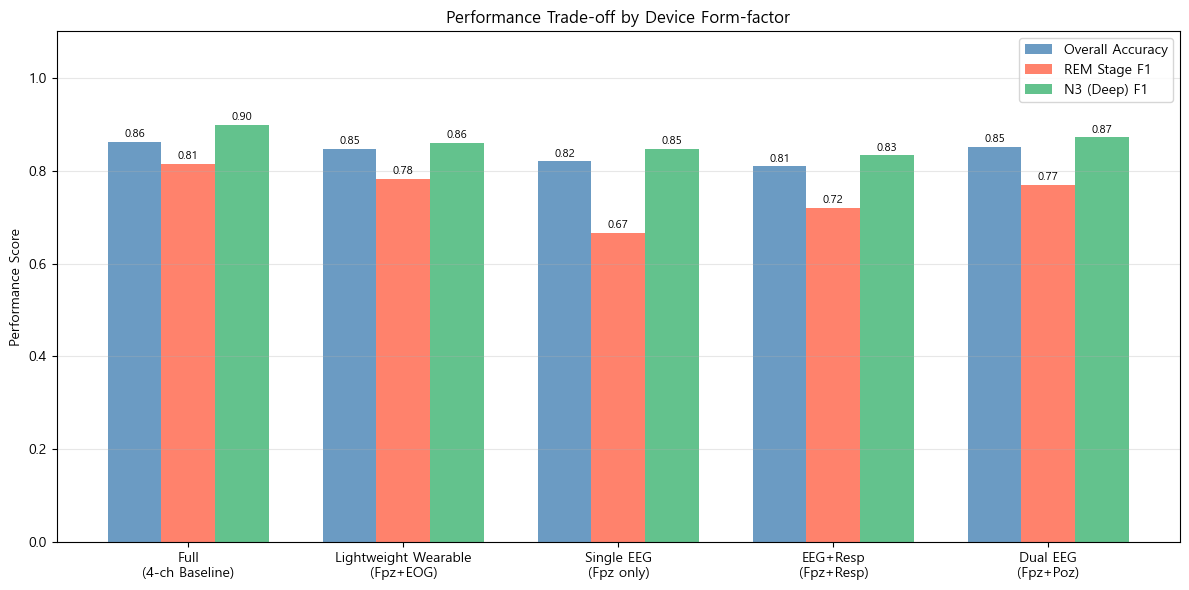


Report: Performance ablation visualization saved.


In [5]:
# STEP 5 — Ablation: Formfactor-wise Channel Comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score

# ── 1. Configuration: Form-factor Channel Sets ────────────────
# Define subsets of channels to simulate different wearable devices
FORMFACTOR_PREFIXES = {
    'Full\n(4-ch Baseline)':          ['fpz_', 'poz_', 'eog_', 'resp_'],
    'Lightweight Wearable\n(Fpz+EOG)': ['fpz_', 'eog_'],
    'Single EEG\n(Fpz only)':          ['fpz_'],
    'EEG+Resp\n(Fpz+Resp)':            ['fpz_', 'resp_'],
    'Dual EEG\n(Fpz+Poz)':             ['fpz_', 'poz_'],
}

# ── 2. Feature Filtering Logic ───────────────────────────────
def filter_features(df, prefixes, feature_names):
    """Filters feature names including temporal (lagged) versions"""
    selected = []
    for fname in feature_names:
        # Strip temporal prefixes to match base channel
        base = fname.replace('prev_', '').replace('next_', '')
        if any(base.startswith(p) for p in prefixes):
            selected.append(fname)
    return selected

# ── 3. Dataset Preparation ────────────────────────────────────
X_all = df.drop(columns=['label']).values
y_all = df['label'].values
results = {}

# ── 4. Ablation Experiment Loop ──────────────────────────────
for formfactor, prefixes in FORMFACTOR_PREFIXES.items():
    # Feature selection for the current form-factor
    selected_features = filter_features(df, prefixes, feature_names)
    selected_idx      = [feature_names.index(f) for f in selected_features]
    X_sub             = X_all[:, selected_idx]

    print(f"\nEvaluating: {formfactor.replace(chr(10), ' ')}")
    print(f"Features utilized: {len(selected_features)}")

    # Consistent split for fair comparison (random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_all, test_size=0.2, stratify=y_all, random_state=42
    )

    # Re-scaling based on the current feature subset
    scaler_sub  = StandardScaler()
    X_train_sub = scaler_sub.fit_transform(X_train)
    X_test_sub  = scaler_sub.transform(X_test)

    model_sub = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                       random_state=42, n_jobs=-1)
    model_sub.fit(X_train_sub, y_train)
    y_pred = model_sub.predict(X_test_sub)

    # Metrics calculation
    acc     = accuracy_score(y_test, y_pred)
    f1_each = f1_score(y_test, y_pred, average=None, labels=[0, 1, 2, 3, 4], zero_division=0)

    results[formfactor] = {
        'accuracy': acc, 'W_f1': f1_each[0], 'N1_f1': f1_each[1],
        'N2_f1': f1_each[2], 'N3_f1': f1_each[3], 'REM_f1': f1_each[4],
        'n_features': len(selected_features), 'model': model_sub,
        'scaler': scaler_sub, 'selected_features': selected_features,
        'X_test': X_test_sub, 'y_test': y_test
    }

    print(f"Accuracy: {acc:.3f} | REM F1: {f1_each[4]:.2f}")

# ── 5. Summary Table ──────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Configuration':<30} {'Feats':>5} {'Acc':>6} {'W':>5} {'N2':>5} {'N3':>5} {'REM':>5}")
print("-" * 70)
for name, r in results.items():
    label = name.replace('\n', ' ')
    print(f"{label:<30} {r['n_features']:>5} {r['accuracy']:>6.3f} "
          f"{r['W_f1']:>5.2f} {r['N2_f1']:>5.2f} {r['N3_f1']:>5.2f} {r['REM_f1']:>5.2f}")

# ── 6. Visualization ──────────────────────────────────────────
labels_plot = list(results.keys())
acc_vals    = [r['accuracy'] for r in results.values()]
rem_f1_vals = [r['REM_f1']   for r in results.values()]
n3_f1_vals  = [r['N3_f1']    for r in results.values()]

x = np.arange(len(labels_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, acc_vals,    width, label='Overall Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x,         rem_f1_vals, width, label='REM Stage F1',     color='tomato',    alpha=0.8)
bars3 = ax.bar(x + width, n3_f1_vals,  width, label='N3 (Deep) F1',     color='mediumseagreen', alpha=0.8)

# Value labels on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Performance Score")
ax.set_title("Performance Trade-off by Device Form-factor")
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("step5_ablation_comparison.png", dpi=150)
plt.show()

print("\nReport: Performance ablation visualization saved.")

In [6]:
# STEP 6a — SHAP Calculation
import shap

# Retrieve models and test data from Step 5 results
full_res = results['Full\n(4-ch Baseline)']
mask_res = results['Lightweight Wearable\n(Fpz+EOG)']

# 1. Full Model (4-channel) SHAP Analysis
explainer_full = shap.TreeExplainer(full_res['model'])
shap_vals_full = explainer_full.shap_values(full_res['X_test'])

# 2. Lightweight Wearable (Fpz+EOG) SHAP Analysis
explainer_mask = shap.TreeExplainer(mask_res['model'])
shap_vals_mask = explainer_mask.shap_values(mask_res['X_test'])

# Summary of SHAP dimensions for verification
print("=== SHAP Analysis Completed ===")
print(f"Full Model SHAP shape: {np.array(shap_vals_full).shape}") # (Stages, Samples, Features)
print(f"Mask Model SHAP shape: {np.array(shap_vals_mask).shape}")

c:\Users\aaww8\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== SHAP Analysis Completed ===
Full Model SHAP shape: (189, 45, 5)
Mask Model SHAP shape: (189, 24, 5)


[Full (4-ch)] fold 1/7 complete - acc: 0.821
[Full (4-ch)] fold 2/7 complete - acc: 0.649
[Full (4-ch)] fold 3/7 complete - acc: 0.744
[Full (4-ch)] fold 4/7 complete - acc: 0.665
[Full (4-ch)] fold 5/7 complete - acc: 0.647
[Full (4-ch)] fold 6/7 complete - acc: 0.637
[Full (4-ch)] fold 7/7 complete - acc: 0.772
[Lightweight Wearable (Fpz+EOG)] fold 1/7 complete - acc: 0.828
[Lightweight Wearable (Fpz+EOG)] fold 2/7 complete - acc: 0.615
[Lightweight Wearable (Fpz+EOG)] fold 3/7 complete - acc: 0.698
[Lightweight Wearable (Fpz+EOG)] fold 4/7 complete - acc: 0.639
[Lightweight Wearable (Fpz+EOG)] fold 5/7 complete - acc: 0.767
[Lightweight Wearable (Fpz+EOG)] fold 6/7 complete - acc: 0.720
[Lightweight Wearable (Fpz+EOG)] fold 7/7 complete - acc: 0.748
[Dual EEG (Fpz+Poz)] fold 1/7 complete - acc: 0.868
[Dual EEG (Fpz+Poz)] fold 2/7 complete - acc: 0.655
[Dual EEG (Fpz+Poz)] fold 3/7 complete - acc: 0.744
[Dual EEG (Fpz+Poz)] fold 4/7 complete - acc: 0.690
[Dual EEG (Fpz+Poz)] fold 5/7

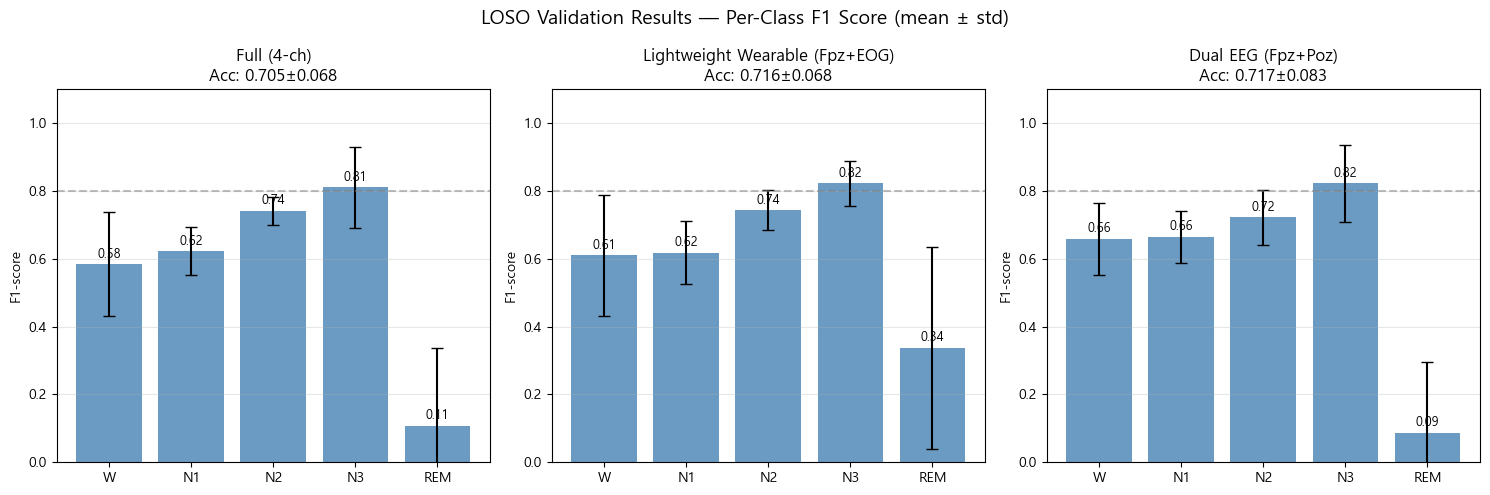


Report: LOSO performance visualization saved.


In [7]:
# # STEP 6b — LOSO Validation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score

# ── 1. Feature Extraction Functions for LOSO ──────────────────
def eeg_band_powers(signal, sfreq=100.0):
    freqs, psd = welch(signal, fs=sfreq, nperseg=256)
    bands = {'delta':(0.5,4), 'theta':(4,8),
             'alpha':(8,12), 'sigma':(12,15), 'beta':(15,30)}
    return {name: np.mean(psd[(freqs>=lo)&(freqs<hi)])
            for name, (lo,hi) in bands.items()}

def eog_features(signal):
    rms      = np.sqrt(np.mean(signal**2))
    zcr      = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
    diff_var = np.var(np.diff(signal))
    return {'rms': rms, 'zcr': zcr, 'diff_var': diff_var}

def resp_features(signal, sfreq=100.0):
    peaks, _ = find_peaks(signal, distance=int(sfreq*2),
                          prominence=np.std(signal)*0.3)
    rate = (len(peaks)/30.0)*60.0 if len(peaks)>0 else 0.0
    return {'rate': rate, 'std': np.std(signal)}

def extract_features(epoch):
    row = {}
    for name, val in eeg_band_powers(epoch[0,:]).items():
        row[f'fpz_{name}'] = val
    for name, val in eeg_band_powers(epoch[1,:]).items():
        row[f'poz_{name}'] = val
    for name, val in eog_features(epoch[2,:]).items():
        row[f'eog_{name}'] = val
    for name, val in resp_features(epoch[3,:]).items():
        row[f'resp_{name}'] = val
    return row

def make_subject_df(subj_data, subj_labels):
    n    = len(subj_data)
    feats = [extract_features(subj_data[i]) for i in range(n)]
    feat_df = pd.DataFrame(feats)

    feat_prev = feat_df.shift(1).bfill()
    feat_next = feat_df.shift(-1).ffill()
    feat_prev.columns = [f'prev_{c}' for c in feat_df.columns]
    feat_next.columns = [f'next_{c}' for c in feat_df.columns]

    combined = pd.concat([feat_df, feat_prev, feat_next], axis=1)
    combined = combined.iloc[1:-1]
    labels   = subj_labels[1:-1]
    return combined, labels

# ── 2. Global Respiration Normalization ──────────────────────
all_resp = np.concatenate([d[:, 3, :] for d in data_per_subj], axis=0)
g_mean   = np.mean(all_resp)
g_std    = np.std(all_resp)

data_per_subj_norm = []
for subj_data in data_per_subj:
    d = subj_data.copy()
    d[:, 3, :] = (d[:, 3, :] - g_mean) / g_std
    data_per_subj_norm.append(d)

# ── 3. Subject-wise DataFrame Generation ──────────────────────
subj_dfs     = []
subj_label_arrays = []

for subj_data, subj_labels in zip(data_per_subj_norm, label_per_subj):
    df_s, lbl_s = make_subject_df(subj_data, subj_labels)
    subj_dfs.append(df_s)
    subj_label_arrays.append(lbl_s)

all_feature_names = subj_dfs[0].columns.tolist()

# ── 4. Form-factor Definitions ────────────────────────────────
FORMFACTOR_PREFIXES = {
    'Full (4-ch)':                    ['fpz_', 'poz_', 'eog_', 'resp_'],
    'Lightweight Wearable (Fpz+EOG)': ['fpz_', 'eog_'],
    'Dual EEG (Fpz+Poz)':             ['fpz_', 'poz_'],
}

def filter_features(feature_names, prefixes):
    selected = []
    for fname in feature_names:
        base = fname.replace('prev_', '').replace('next_', '')
        if any(base.startswith(p) for p in prefixes):
            selected.append(fname)
    return selected

# ── 5. LOSO (Leave-One-Subject-Out) Loop ──────────────────────
n_subjects = len(subj_dfs)
loso_results = {}

for formfactor, prefixes in FORMFACTOR_PREFIXES.items():
    selected_features = filter_features(all_feature_names, prefixes)
    fold_accs   = []
    fold_f1s    = [] 

    for test_idx in range(n_subjects):
        # Prepare test fold
        X_test_raw  = subj_dfs[test_idx][selected_features].values
        y_test_fold = subj_label_arrays[test_idx]

        # Prepare train fold (exclude test_idx)
        X_train_parts = [subj_dfs[i][selected_features].values
                         for i in range(n_subjects) if i != test_idx]
        y_train_parts = [subj_label_arrays[i]
                         for i in range(n_subjects) if i != test_idx]

        X_train_raw = np.concatenate(X_train_parts, axis=0)
        y_train_fold = np.concatenate(y_train_parts, axis=0)

        scaler_loso = StandardScaler()
        X_train_s   = scaler_loso.fit_transform(X_train_raw)
        X_test_s    = scaler_loso.transform(X_test_raw)

        model_loso = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=42, n_jobs=-1)
        model_loso.fit(X_train_s, y_train_fold)
        y_pred_fold = model_loso.predict(X_test_s)

        fold_accs.append(accuracy_score(y_test_fold, y_pred_fold))
        fold_f1s.append(f1_score(y_test_fold, y_pred_fold,
                                  average=None, labels=[0,1,2,3,4],
                                  zero_division=0))

        print(f"[{formfactor}] fold {test_idx+1}/7 complete - acc: {fold_accs[-1]:.3f}")

    fold_f1s = np.array(fold_f1s)
    loso_results[formfactor] = {
        'acc_mean':  np.mean(fold_accs),
        'acc_std':   np.std(fold_accs),
        'f1_mean':   fold_f1s.mean(axis=0),
        'f1_std':    fold_f1s.std(axis=0),
    }

# ── 6. Final Report ───────────────────────────────────────────
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']

print("\n\n" + "="*85)
print("LOSO VALIDATION SUMMARY")
print(f"{'Configuration':<35} {'Acc(mean±std)':>18} "
      f"{'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5}")
print("-" * 85)
for name, r in loso_results.items():
    f1m = r['f1_mean']
    print(f"{name:<35} {r['acc_mean']:.3f}±{r['acc_std']:.3f}   "
          f"{f1m[0]:.2f} {f1m[1]:.2f} {f1m[2]:.2f} {f1m[3]:.2f} {f1m[4]:.2f}")

# ── 7. Comparison: Random Split vs. LOSO ──────────────────────
print("\n=== Benchmark Comparison (Lightweight Wearable) ===")
rs_name   = 'Lightweight Wearable (Fpz+EOG)' 
loso_name = 'Lightweight Wearable (Fpz+EOG)'

if rs_name in results:
    rs   = results[rs_name]
    loso = loso_results[loso_name]

    print(f"{'Method':30} {'Acc':>8} {'REM F1':>8}")
    print(f"{'Random Split':30} {rs['accuracy']:>8.3f} {rs['REM_f1']:>8.3f}")
    print(f"{'LOSO Validation':30} {loso['acc_mean']:>8.3f} {loso['f1_mean'][4]:>8.3f}")
    print(f"{'Performance Gap':30} {rs['accuracy']-loso['acc_mean']:>8.3f} "
          f"{rs['REM_f1']-loso['f1_mean'][4]:>8.3f}")

# ── 8. Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, r) in zip(axes, loso_results.items()):
    f1m = r['f1_mean']
    f1s = r['f1_std']

    bars = ax.bar(stage_names, f1m, color='steelblue', alpha=0.8)
    ax.errorbar(stage_names, f1m, yerr=f1s, fmt='none', color='black', capsize=4)
    
    for bar, val in zip(bars, f1m):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center', fontsize=9)

    ax.set_ylim(0, 1.1)
    ax.set_title(f"{name}\nAcc: {r['acc_mean']:.3f}±{r['acc_std']:.3f}")
    ax.set_ylabel("F1-score")
    ax.axhline(y=0.80, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("LOSO Validation Results — Per-Class F1 Score (mean ± std)", fontsize=14)
plt.tight_layout()
plt.savefig("step5_loso_result.png", dpi=150)
plt.show()

print("\nReport: LOSO performance visualization saved.")

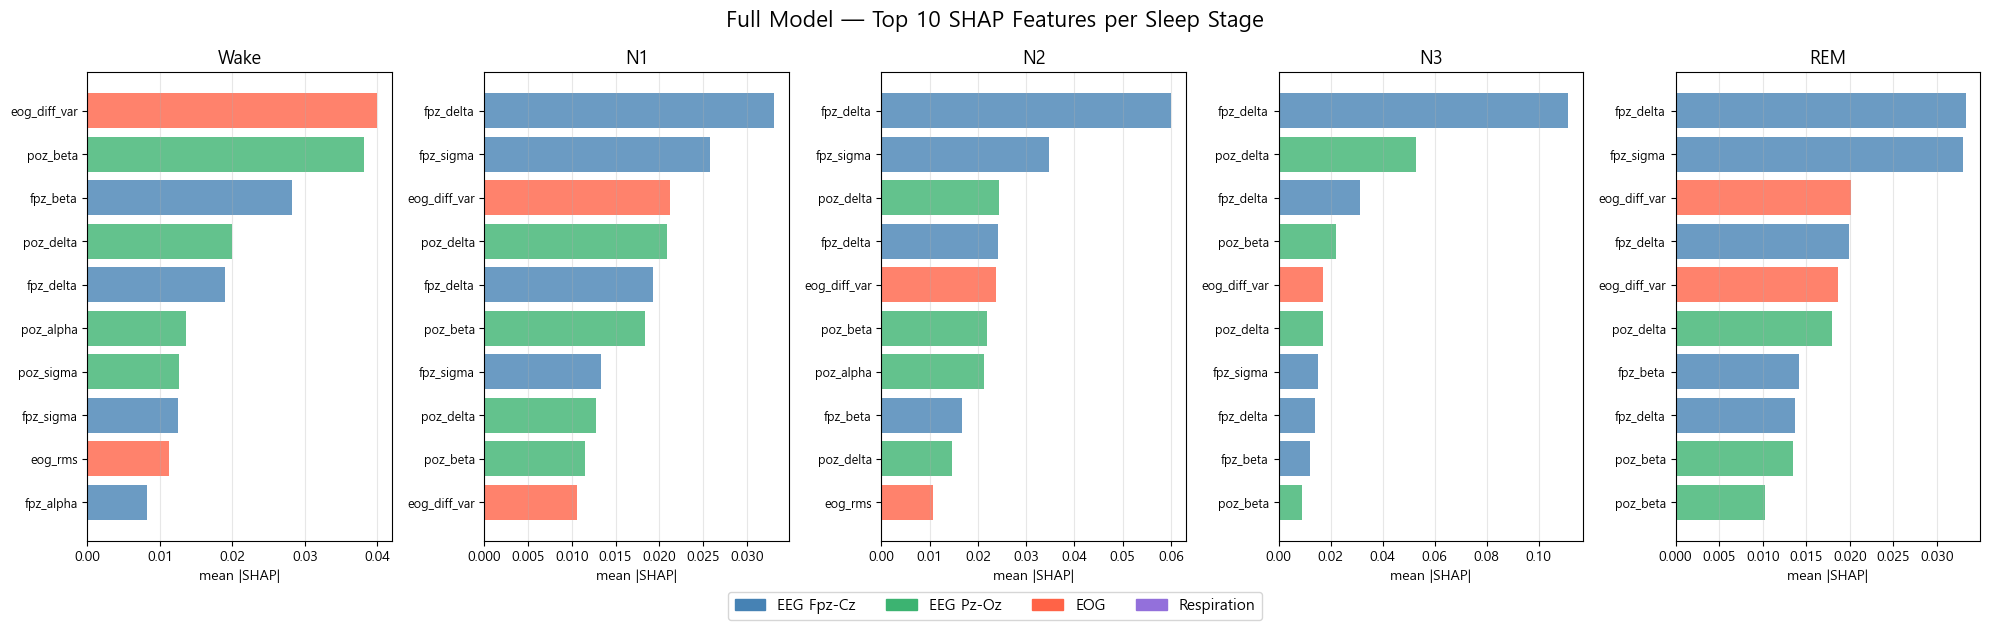

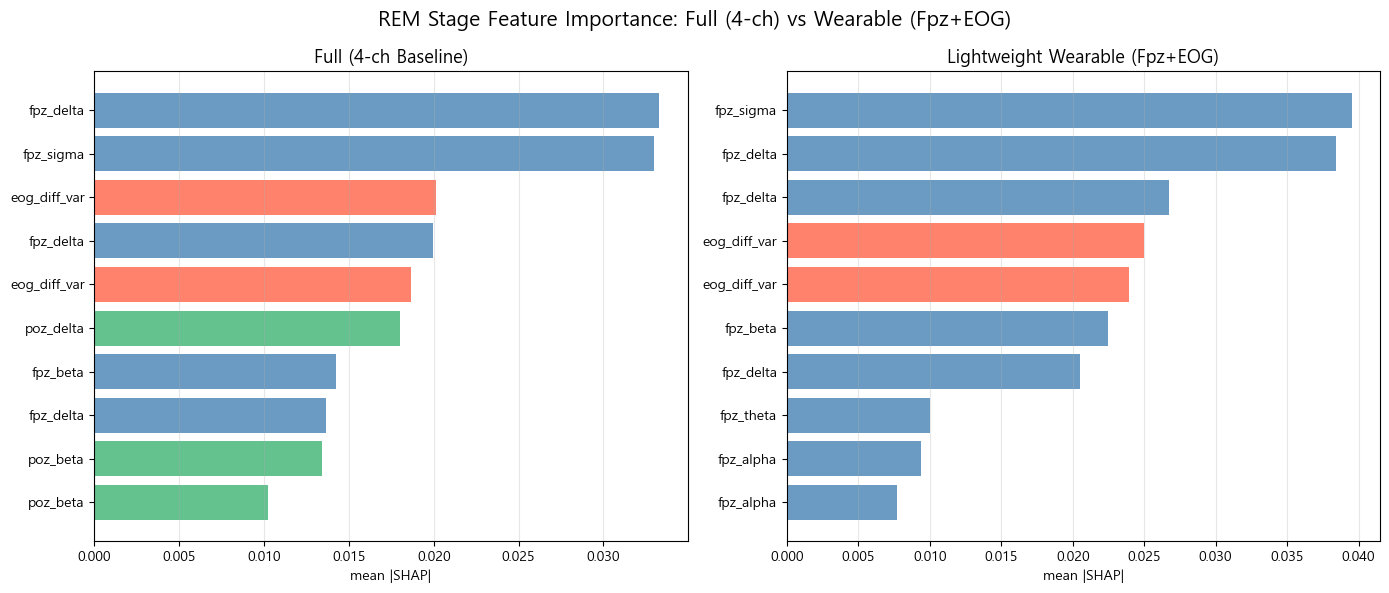


FULL MODEL — MEAN SHAP ATTRIBUTION PER CHANNEL
Stage          EEG Fpz     EEG Poz         EOG        Resp
-----------------------------------------------------------------
Wake            0.0070      0.0077      0.0075      0.0010
N1              0.0101      0.0080      0.0064      0.0013
N2              0.0128      0.0094      0.0067      0.0018
N3              0.0149      0.0101      0.0044      0.0012
REM             0.0099      0.0058      0.0064      0.0016


In [8]:
# STEP 7 — SHAP Visualization & Attribution Analysis
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Set stage names for visualization
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

# ── 1. Full Model — Top 10 SHAP Features per Sleep Stage ───────────────────
full_res      = results['Full\n(4-ch Baseline)']
full_features = full_res['selected_features']  # 여기서 정의가 되어야 합니다!

mask_res      = results['Lightweight Wearable\n(Fpz+EOG)']
mask_features = mask_res['selected_features']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle("Full Model — Top 10 SHAP Features per Sleep Stage", fontsize=16)

for class_idx, stage in enumerate(stage_names):
    ax = axes[class_idx]

    # Slice SHAP values for the specific class: (n_samples, n_features)
    shap_class     = shap_vals_full[:, :, class_idx]
    shap_abs_mean = np.abs(shap_class).mean(axis=0)

    top10_idx   = np.argsort(shap_abs_mean)[::-1][:10]
    top10_val   = shap_abs_mean[top10_idx]
    top10_names = [full_features[i].replace('prev_','').replace('next_','')
                   for i in top10_idx]

    # Color mapping based on sensor type
    colors = ['tomato'         if 'eog'  in n else
              'steelblue'      if 'fpz'  in n else
              'mediumseagreen' if 'poz'  in n else
              'mediumpurple'
              for n in top10_names]

    ax.barh(range(10), top10_val[::-1], color=colors[::-1], alpha=0.8)
    ax.set_yticks(range(10))
    ax.set_yticklabels(top10_names[::-1], fontsize=9)
    ax.set_title(f"{stage}", fontsize=13)
    ax.set_xlabel("mean |SHAP|", fontsize=10)
    ax.grid(axis='x', alpha=0.3)

legend_elements = [
    Patch(color='steelblue',      label='EEG Fpz-Cz'),
    Patch(color='mediumseagreen', label='EEG Pz-Oz'),
    Patch(color='tomato',         label='EOG'),
    Patch(color='mediumpurple',   label='Respiration'),
]
fig.legend(handles=legend_elements, loc='lower center',
            ncol=4, fontsize=11, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("step6_full_shap_per_stage.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Full vs Lightweight Wearable — REM Attribution Comparison ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("REM Stage Feature Importance: Full (4-ch) vs Wearable (Fpz+EOG)", fontsize=15)

titles = ['Full (4-ch Baseline)', 'Lightweight Wearable (Fpz+EOG)']

for ax, shap_vals, features, title in zip(
    axes,
    [shap_vals_full, shap_vals_mask],
    [full_features,  mask_features],
    titles
):
    # REM = Class Index 4
    shap_class     = shap_vals[:, :, 4]
    shap_abs_mean = np.abs(shap_class).mean(axis=0)
    top10_idx     = np.argsort(shap_abs_mean)[::-1][:10]
    top10_val     = shap_abs_mean[top10_idx]
    top10_names   = [features[i].replace('prev_','').replace('next_','')
                     for i in top10_idx]

    colors = ['tomato'         if 'eog'  in n else
              'steelblue'      if 'fpz'  in n else
              'mediumseagreen' if 'poz'  in n else
              'mediumpurple'
              for n in top10_names]

    ax.barh(range(10), top10_val[::-1], color=colors[::-1], alpha=0.8)
    ax.set_yticks(range(10))
    ax.set_yticklabels(top10_names[::-1], fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("mean |SHAP|", fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("step6_rem_shap_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Channel-wise Attribution Table (Console Output) ─────────────────────
def channel_importance(shap_vals_3d, class_idx, features):
    shap_class = shap_vals_3d[:, :, class_idx]
    channel_map = {
        'EEG Fpz': 'fpz_',
        'EEG Poz': 'poz_',
        'EOG':     'eog_',
        'Resp':    'resp_'
    }
    result = {}
    for ch_name, prefix in channel_map.items():
        idx = [i for i, f in enumerate(features)
               if f.replace('prev_','').replace('next_','').startswith(prefix)]
        if idx:
            result[ch_name] = np.abs(shap_class[:, idx]).mean()
    return result

print("\n" + "="*65)
print("FULL MODEL — MEAN SHAP ATTRIBUTION PER CHANNEL")
channels = ['EEG Fpz', 'EEG Poz', 'EOG', 'Resp']
print(f"{'Stage':<10}", end="")
for ch in channels:
    print(f"{ch:>12}", end="")
print("\n" + "-"*65)

for class_idx, stage in enumerate(stage_names):
    imp = channel_importance(shap_vals_full, class_idx, full_features)
    print(f"{stage:<10}", end="")
    for ch in channels:
        print(f"{imp.get(ch, 0):>12.4f}", end="")
    print()